# Diversification Doesn't Fail Slowly
### Project 1 — The Diversification Series

This notebook investigates the speed at which diversification benefits collapse during systemic market stress.

The central claim is not that diversification has no effect — the average benefit over long horizons is real.  
The claim is more precise: **this benefit is regime-dependent, collapses rapidly under stress, and does not become more reliable with a broader asset universe.**

---

**Two-block architecture:**
- **Block A** — 3 assets (SPX, Treasury, Gold), data from 1980. Structural analysis.
- **Block B** — 7 ETFs (SPY, EFA, EEM, TLT, IEF, GLD, DBC), data from 2006. Investable universe.

GFC and COVID appear in both blocks with identical definitions — enabling direct cross-block comparison.

---
*No look-ahead bias. All rolling thresholds use only data available at time t (252-day rolling window, shifted 1 day).*

## 1. Setup

In [552]:
import numpy as np
import pandas as pd
import yfinance as yf
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)

print("✓ Imports OK")

✓ Imports OK


## 2. Parameters

In [553]:
# ── Date ranges ──────────────────────────────────────────────
START_A = "1980-01-01"
START_B = "2006-01-01"
END     = "2024-12-31"

# ── Block A assets ────────────────────────────────────────────
TICKERS_A      = ["SPX", "Treasury", "DXY"]
RISK_ASSETS_A  = ["SPX"]
DEF_ASSETS_A   = ["Treasury", "DXY"]

# ── Block B tickers ──────────────────────────────────────────
TICKERS_B      = ["SPY", "EFA", "EEM", "TLT", "IEF", "GLD", "DBC"]
RISK_ASSETS_B  = ["SPY", "EFA", "EEM", "DBC"]
DEF_ASSETS_B   = ["TLT", "IEF", "GLD"]

# ── Analysis parameters ──────────────────────────────────────
ROLL_CORR       = 20    # rolling window for correlation and volatility (days)
ROLL_THRESH     = 252   # rolling window for threshold calibration (days)
CORR_PCTILE     = 0.90  # percentile for correlation collapse threshold
DURATION_APPROX = 8.5   # Treasury duration approximation (Block A)

# ── Algorithmic episode detection parameters ──────────────────
ALGO_DD_START   = 0.15  # drawdown threshold to enter stress (15%)
ALGO_DD_END     = 0.20  # drawdown threshold component to exit stress (20%)
ALGO_RECOVERY   = 0.075 # recovery from trough required to exit stress (7.5%)

# ── Cross-block episodes (for H5) ─────────────────────────────
CROSS_BLOCK_LABELS = ["GFC", "COVID"]  # narrative labels for reference only

print("✓ Parameters set")
print(f"  Block A assets   : {TICKERS_A}")
print(f"  Block A risk     : {RISK_ASSETS_A}")
print(f"  Block B assets   : {TICKERS_B}")
print(f"  Block B risk     : {RISK_ASSETS_B}")
print(f"  Algo DD start    : {ALGO_DD_START:.0%}")
print(f"  Algo DD end      : {ALGO_DD_END:.0%}")
print(f"  Algo recovery    : {ALGO_RECOVERY:.1%}")

✓ Parameters set
  Block A assets   : ['SPX', 'Treasury', 'DXY']
  Block A risk     : ['SPX']
  Block B assets   : ['SPY', 'EFA', 'EEM', 'TLT', 'IEF', 'GLD', 'DBC']
  Block B risk     : ['SPY', 'EFA', 'EEM', 'DBC']
  Algo DD start    : 15%
  Algo DD end      : 20%
  Algo recovery    : 7.5%


## 3. Data Collection

### 3.1 Utility functions

In [554]:
def download_price_series(ticker: str, name: str, start: str, end: str) -> pd.Series:
    """
    Download daily adjusted close prices from Yahoo Finance.
    Returns a named Series indexed by date.
    """
    raw = yf.download(ticker, start=start, end=end,
                      auto_adjust=True, progress=False)

    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)

    s = raw["Close"].copy()
    s.index = pd.to_datetime(s.index)
    s = s.sort_index()
    s.name = name
    return s


def align_to_intersection(series_dict: dict) -> pd.DataFrame:
    """
    Align multiple Series to their common trading dates (calendar intersection).
    No forward-fill. No imputation.
    Returns a DataFrame with only dates where all assets have observed returns.
    """
    df = pd.concat(series_dict.values(), axis=1)
    df.columns = list(series_dict.keys())
    df = df.dropna(how='any')
    return df


print("✓ Utility functions defined")

✓ Utility functions defined


### 3.2 Block A — Core assets, long history (1980–2024)

In [555]:
# ── SPX ───────────────────────────────────────────────────────
spx_prices = download_price_series("^GSPC", "SPX", START_A, END)
spx_ret    = spx_prices.pct_change().dropna()
spx_ret.name = "SPX"

# ── Treasury — DGS10 via FRED ─────────────────────────────────
# Series in percent (e.g. 4.5 = 4.5%) — divide by 100 before duration approx
dgs10_raw = web.DataReader("DGS10", "fred", START_A, END)["DGS10"].dropna()
dgs10_raw.index = pd.to_datetime(dgs10_raw.index)
treasury_ret = (-DURATION_APPROX * dgs10_raw.diff() / 100).dropna()
treasury_ret.name = "Treasury"

# ── DXY — US Dollar Index via Yahoo Finance ───────────────────
dxy_prices = download_price_series("DX-Y.NYB", "DXY", START_A, END)
dxy_ret    = dxy_prices.pct_change().dropna()
dxy_ret.name = "DXY"

# Note: LBMA Gold series (GOLDAMGBD228NLBM) was permanently removed from
# FRED in January 2022. Block A uses SPX, Treasury, and DXY — three
# structurally distinct assets available since 1980.
# Gold is included in Block B via GLD ETF (2006 onward).

# ── Align to calendar intersection ────────────────────────────
ret_a = align_to_intersection({
    "SPX"     : spx_ret,
    "Treasury": treasury_ret,
    "DXY"     : dxy_ret,
})

# ── Sanity check ──────────────────────────────────────────────
print("Block A — Returns")
print(f"  Period : {ret_a.index[0].date()} → {ret_a.index[-1].date()}")
print(f"  Obs    : {len(ret_a)}")
print(f"  Assets : {list(ret_a.columns)}")
print(f"  NaNs   : {ret_a.isna().sum().sum()}")
print()
print(ret_a.describe().round(4))

Block A — Returns
  Period : 1980-01-03 → 2024-12-30
  Obs    : 11237
  Assets : ['SPX', 'Treasury', 'DXY']
  NaNs   : 0

             SPX   Treasury        DXY
count 11237.0000 11237.0000 11237.0000
mean      0.0004     0.0000     0.0000
std       0.0112     0.0062     0.0052
min      -0.2047    -0.0553    -0.0348
25%      -0.0046    -0.0034    -0.0029
50%       0.0006     0.0000     0.0000
75%       0.0057     0.0034     0.0030
max       0.1079     0.0638     0.0290


### 3.3 Block B — Expanded universe, modern period (2006–2024)

In [556]:
# ── Download ETF prices ───────────────────────────────────────
prices_b_raw = yf.download(
    TICKERS_B, start=START_B, end=END,
    auto_adjust=True, progress=False
)["Close"]

if isinstance(prices_b_raw.columns, pd.MultiIndex):
    prices_b_raw.columns = prices_b_raw.columns.get_level_values(0)

prices_b_raw = prices_b_raw[TICKERS_B]
prices_b_raw.index = pd.to_datetime(prices_b_raw.index)

# ── Returns and calendar intersection ────────────────────────
ret_b = prices_b_raw.pct_change().dropna(how='any')

# ── Sanity check ─────────────────────────────────────────────
print("Block B — Returns")
print(f"  Period : {ret_b.index[0].date()} → {ret_b.index[-1].date()}")
print(f"  Obs    : {len(ret_b)}")
print(f"  Assets : {list(ret_b.columns)}")
print(f"  NaNs   : {ret_b.isna().sum().sum()}")
print()
print(ret_b.describe().round(4))

Block B — Returns
  Period : 2006-02-07 → 2024-12-30
  Obs    : 4756
  Assets : ['SPY', 'EFA', 'EEM', 'TLT', 'IEF', 'GLD', 'DBC']
  NaNs   : 0

Ticker       SPY       EFA       EEM       TLT       IEF       GLD       DBC
count  4756.0000 4756.0000 4756.0000 4756.0000 4756.0000 4756.0000 4756.0000
mean      0.0005    0.0003    0.0003    0.0002    0.0001    0.0004    0.0001
std       0.0122    0.0137    0.0179    0.0095    0.0044    0.0112    0.0122
min      -0.1094   -0.1116   -0.1617   -0.0667   -0.0251   -0.0878   -0.0794
25%      -0.0040   -0.0054   -0.0079   -0.0055   -0.0025   -0.0052   -0.0063
50%       0.0007    0.0007    0.0008    0.0004    0.0002    0.0005    0.0006
75%       0.0059    0.0066    0.0085    0.0057    0.0026    0.0061    0.0068
max       0.1452    0.1589    0.2277    0.0752    0.0343    0.1129    0.0687


### 3.4 Save and reload data (reproducibility)

In [557]:
import os

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

FILE_A = os.path.join(DATA_DIR, "ret_a.csv")
FILE_B = os.path.join(DATA_DIR, "ret_b.csv")

# Save if not already saved
if not os.path.exists(FILE_A):
    ret_a.to_csv(FILE_A)
    print(f"✓ Saved: {FILE_A}")
else:
    ret_a = pd.read_csv(FILE_A, index_col=0, parse_dates=True)
    print(f"✓ Loaded from cache: {FILE_A}")

if not os.path.exists(FILE_B):
    ret_b.to_csv(FILE_B)
    print(f"✓ Saved: {FILE_B}")
else:
    ret_b = pd.read_csv(FILE_B, index_col=0, parse_dates=True)
    print(f"✓ Loaded from cache: {FILE_B}")

print(f"\nBlock A: {ret_a.shape[0]} obs | Block B: {ret_b.shape[0]} obs")

✓ Loaded from cache: data\ret_a.csv
✓ Loaded from cache: data\ret_b.csv

Block A: 11237 obs | Block B: 4756 obs


## 4. Regime Classification & Rolling Metrics

### 4.1 Utility functions — regimes and metrics

In [558]:
def detect_stress_episodes(spx_ret: pd.Series,
                            spx_prices: pd.Series,
                            dd_start: float = ALGO_DD_START,
                            dd_end: float   = ALGO_DD_END,
                            recovery: float = ALGO_RECOVERY) -> list:
    """
    Detect stress episodes algorithmically — no manual selection.

    Entry : SPX drawdown from rolling 252-day peak < -dd_start
            AND SPX price < MA200 (shifted 1 day)
    Exit  : SPX price > MA200
            AND drawdown > -dd_end (if entry DD < -dd_end)
            OR  drawdown recovered recovery% from entry DD
                (if entry DD between -dd_start and -dd_end)

    Returns list of (start_date, end_date) tuples.
    """
    # Cumulative equity level from returns
    spx_level    = (1 + spx_ret).cumprod()
    rolling_peak = spx_level.rolling(window=ROLL_THRESH, min_periods=1).max()
    drawdown     = (spx_level - rolling_peak) / rolling_peak

    # MA200 shifted 1 day — no look-ahead
    ma200 = spx_prices.rolling(200).mean().shift(1)
    ma200 = ma200.reindex(spx_ret.index)

    in_episode  = False
    episodes    = []
    start_date  = None
    dd_at_entry = None

    for date in drawdown.index:
        dd  = drawdown.loc[date]
        spx = spx_prices.reindex([date]).iloc[0] if date in spx_prices.index else float('nan')
        ma  = ma200.loc[date] if date in ma200.index else float('nan')

        if any(map(lambda x: x != x, [dd, spx, ma])):  # NaN check
            continue

        if not in_episode:
            if dd < -dd_start and spx < ma:
                in_episode  = True
                start_date  = date
                dd_at_entry = dd
        else:
            if spx > ma:
                if dd_at_entry < -dd_end:
                    exit_ok = dd > -dd_end
                else:
                    exit_ok = dd > (dd_at_entry + recovery)
                if exit_ok:
                    episodes.append((start_date, date))
                    in_episode  = False
                    start_date  = None
                    dd_at_entry = None

    if in_episode:
        episodes.append((start_date, drawdown.index[-1]))

    return episodes


def classify_regimes_algo(ret: pd.DataFrame, spx_col: str,
                           episodes: list) -> pd.DataFrame:
    """
    Classify each date as stress or normal using algorithmic episodes.
    episodes: list of (start_date, end_date) tuples
    stress_onset = first day of each episode.
    """
    result = pd.DataFrame(index=ret.index)
    result["regime"]       = "normal"
    result["episode"]      = None
    result["stress_onset"] = False

    for i, (start, end) in enumerate(episodes):
        mask        = (ret.index >= start) & (ret.index <= end)
        episode_idx = ret.index[mask]
        if len(episode_idx) == 0:
            continue
        ep_name = f"ep_{i+1:02d}_{start.date()}"
        result.loc[episode_idx, "episode"] = ep_name
        result.loc[episode_idx, "regime"]  = "stress"
        result.loc[episode_idx[0], "stress_onset"] = True

    return result


def rolling_avg_pairwise_corr(ret: pd.DataFrame, window: int = ROLL_CORR) -> pd.Series:
    """
    Rolling average pairwise correlation.
    Full correlation matrix. Diagonal removed. Mean over unique pairs (upper triangle).
    """
    n = ret.shape[1]
    if n < 2:
        raise ValueError("Need at least 2 assets.")

    results = []
    for i in range(len(ret)):
        if i < window - 1:
            results.append(np.nan)
            continue
        window_data = ret.iloc[i - window + 1 : i + 1]
        corr_matrix = window_data.corr()
        upper = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )
        avg_corr = upper.stack().mean()
        results.append(avg_corr)

    return pd.Series(results, index=ret.index, name="avg_pairwise_corr")


def rolling_avg_pairwise_corr_subset(ret: pd.DataFrame, assets: list,
                                      window: int = ROLL_CORR) -> pd.Series:
    """
    Rolling average pairwise correlation restricted to a subset of assets.
    Used to isolate risk asset correlation from defensive asset correlation.
    """
    ret_sub = ret[assets]
    s = rolling_avg_pairwise_corr(ret_sub, window=window)
    s.name = "avg_corr_risk"
    return s


def rolling_diversification_ratio(ret: pd.DataFrame, window: int = ROLL_CORR) -> pd.Series:
    """
    Diversification Ratio = mean(individual asset vols) / portfolio vol.
    Rolling window, simple daily returns, non-annualized, equally weighted.
    """
    results  = []
    n_assets = ret.shape[1]
    weights  = np.ones(n_assets) / n_assets

    for i in range(len(ret)):
        if i < window - 1:
            results.append(np.nan)
            continue
        window_data     = ret.iloc[i - window + 1 : i + 1]
        individual_vols = window_data.std()
        portfolio_ret   = window_data.dot(weights)
        portfolio_vol   = portfolio_ret.std()
        if portfolio_vol == 0:
            results.append(np.nan)
            continue
        dr = individual_vols.mean() / portfolio_vol
        results.append(dr)

    return pd.Series(results, index=ret.index, name="diversification_ratio")


def rolling_corr_threshold(avg_corr: pd.Series,
                            window: int  = ROLL_THRESH,
                            pctile: float = CORR_PCTILE) -> pd.Series:
    """
    Rolling 252-day percentile threshold for correlation collapse detection.
    Shifted 1 day — no look-ahead bias.
    """
    threshold = (
        avg_corr
        .rolling(window=window, min_periods=window // 2)
        .quantile(pctile)
        .shift(1)
    )
    threshold.name = "corr_threshold"
    return threshold


print("✓ Utility functions defined")

✓ Utility functions defined


### 4.2 Block A — regime classification and rolling metrics

In [559]:
# ── Download SPX prices for episode detection ─────────────────
spx_prices_full = download_price_series("^GSPC", "SPX", START_A, END)

# ── Detect algorithmic stress episodes ───────────────────────
algo_eps_all = detect_stress_episodes(
    spx_ret    = ret_a["SPX"],
    spx_prices = spx_prices_full.reindex(ret_a.index),
    dd_start   = ALGO_DD_START,
    dd_end     = ALGO_DD_END,
    recovery   = ALGO_RECOVERY
)

# ── Regime classification — Block A ───────────────────────────
regimes_a = classify_regimes_algo(ret_a, "SPX", algo_eps_all)

# ── Rolling metrics ───────────────────────────────────────────
avg_corr_a = rolling_avg_pairwise_corr(ret_a)
dr_a       = rolling_diversification_ratio(ret_a)
corr_th_a  = rolling_corr_threshold(avg_corr_a)

# ── Combine ───────────────────────────────────────────────────
metrics_a = pd.concat([ret_a, regimes_a, avg_corr_a, dr_a, corr_th_a], axis=1)

# ── Sanity check ──────────────────────────────────────────────
print("Block A — Algorithmic Episode Detection")
print(f"  Total obs    : {len(metrics_a)}")
print(f"  Normal days  : {(metrics_a['regime'] == 'normal').sum()}")
print(f"  Stress days  : {(metrics_a['regime'] == 'stress').sum()}")
print()
print("Episodes detected:")
for ep in metrics_a['episode'].dropna().unique():
    ep_dates = metrics_a[metrics_a['episode'] == ep].index
    dd_max   = ((1 + ret_a["SPX"]).cumprod() /
                (1 + ret_a["SPX"]).cumprod().rolling(ROLL_THRESH, min_periods=1).max() - 1
               ).loc[ep_dates].min()
    print(f"  {ep} | {len(ep_dates):3d} dias | max DD: {dd_max:.1%}")

Block A — Algorithmic Episode Detection
  Total obs    : 11237
  Normal days  : 9111
  Stress days  : 2126

Episodes detected:
  ep_01_1981-09-08 | 242 dias | max DD: -23.8%
  ep_02_1987-10-16 | 252 dias | max DD: -33.9%
  ep_03_1990-08-23 | 109 dias | max DD: -20.4%
  ep_04_1998-08-31 |  17 dias | max DD: -19.3%
  ep_05_1998-10-01 |  21 dias | max DD: -19.2%
  ep_06_2000-12-20 | 606 dias | max DD: -34.0%
  ep_07_2008-01-22 | 432 dias | max DD: -56.5%
  ep_08_2010-06-30 |  23 dias | max DD: -16.0%
  ep_09_2011-08-08 |  57 dias | max DD: -19.4%
  ep_10_2011-11-17 |  46 dias | max DD: -19.4%
  ep_11_2018-12-21 |  35 dias | max DD: -18.1%
  ep_12_2020-03-09 |  56 dias | max DD: -33.9%
  ep_13_2022-05-09 | 230 dias | max DD: -25.2%


### 4.3 Block B — regime classification and rolling metrics

In [560]:
# ── Filter episodes overlapping Block B period ────────────────
start_b       = pd.Timestamp(START_B)
algo_eps_b    = [(s, e) for s, e in algo_eps_all if e >= start_b]

# ── Regime classification — Block B ───────────────────────────
regimes_b = classify_regimes_algo(ret_b, "SPY", algo_eps_b)

# ── Rolling metrics — full universe ───────────────────────────
avg_corr_b = rolling_avg_pairwise_corr(ret_b)
dr_b       = rolling_diversification_ratio(ret_b)
corr_th_b  = rolling_corr_threshold(avg_corr_b)

# ── Risk asset correlation ────────────────────────────────────
avg_corr_risk_b  = rolling_avg_pairwise_corr_subset(ret_b, RISK_ASSETS_B)
corr_th_risk_b   = rolling_corr_threshold(avg_corr_risk_b)
corr_th_risk_b.name = "corr_threshold_risk"

# ── Combine ───────────────────────────────────────────────────
metrics_b = pd.concat([ret_b, regimes_b, avg_corr_b, dr_b, corr_th_b,
                        avg_corr_risk_b, corr_th_risk_b], axis=1)

# ── Sanity check ──────────────────────────────────────────────
print("Block B — Algorithmic Episodes")
print(f"  Total obs    : {len(metrics_b)}")
print(f"  Normal days  : {(metrics_b['regime'] == 'normal').sum()}")
print(f"  Stress days  : {(metrics_b['regime'] == 'stress').sum()}")
print()
print("Episodes detected:")
for ep in metrics_b['episode'].dropna().unique():
    ep_dates = metrics_b[metrics_b['episode'] == ep].index
    print(f"  {ep} | {len(ep_dates):3d} dias")
print()
print("Risk correlation by episode:")
normal_risk = metrics_b.loc[metrics_b["regime"] == "normal", "avg_corr_risk"].mean()
print(f"  Normal baseline: {normal_risk:.4f}")
for ep in metrics_b['episode'].dropna().unique():
    ep_data = metrics_b.loc[metrics_b["episode"] == ep, "avg_corr_risk"].dropna()
    if len(ep_data) > 0:
        print(f"  {ep}: mean={ep_data.mean():.4f}  max={ep_data.max():.4f}")

Block B — Algorithmic Episodes
  Total obs    : 4756
  Normal days  : 3872
  Stress days  : 884

Episodes detected:
  ep_01_2008-01-22 | 434 dias
  ep_02_2010-06-30 |  23 dias
  ep_03_2011-08-08 |  58 dias
  ep_04_2011-11-17 |  46 dias
  ep_05_2018-12-21 |  35 dias
  ep_06_2020-03-09 |  56 dias
  ep_07_2022-05-09 | 232 dias

Risk correlation by episode:
  Normal baseline: 0.5771
  ep_01_2008-01-22: mean=0.6487  max=0.9176
  ep_02_2010-06-30: mean=0.7985  max=0.8626
  ep_03_2011-08-08: mean=0.8374  max=0.8916
  ep_04_2011-11-17: mean=0.8153  max=0.9156
  ep_05_2018-12-21: mean=0.6822  max=0.7709
  ep_06_2020-03-09: mean=0.7657  max=0.9027
  ep_07_2022-05-09: mean=0.5907  max=0.8446


## 5. Hypothesis Testing

### 5.0 Note on hypothesis scope by block

**H1 (correlation collapse)** is tested on Block B only.

Block A contains 3 assets (SPX, Treasury, DXY) with historically negative
average pairwise correlation. With only 3 pairs, the average correlation metric
is dominated by the SPX-Treasury relationship, which is negative by regime —
not a diversification signal. This makes H1 untestable in a meaningful way
with this universe.

Block A contributes to H2 (speed of collapse), H3 (diversification ratio),
and H4 (breadth) — metrics that are informative regardless of correlation sign.

This limitation was identified empirically and is declared before results are reported.

**Rolling window noise in Block A:** With only 3 asset pairs in Block A,
the rolling 20-day average pairwise correlation is computed over a small
number of unique pairs. This makes the metric noisier than in Block B
(6 unique pairs among risk assets alone). Results for Block A correlation
metrics should be interpreted with this in mind.

**Black Monday onset (Block A):** The detected onset date is 1987-10-01,
reflecting the SPX drawdown threshold being crossed during the gradual
decline that preceded the crash. The crash itself occurred on 1987-10-19.
This is consistent with the operational definition — onset is the first
day drawdown exceeds 10%, not the maximum drawdown day. The implication
is that speed measurement for Black Monday, if it were computable, would
be measured from the pre-crash decline, not from the crash date itself.
This is declared for transparency.

### 5.1 H1 — Correlation collapse under stress

In [561]:
def test_h1(metrics: pd.DataFrame, block_name: str) -> pd.DataFrame:
    """
    H1: Average pairwise correlation among risk assets is materially
    higher in stress regimes than in normal regimes.
    Test: Mann-Whitney U (one-sided: stress > normal).
    Metric: avg_corr_risk (risk assets only — SPY, EFA, EEM, DBC).
    Tested on Block B only — see methodological note in 5.0.
    """
    stress = metrics.loc[metrics["regime"] == "stress", "avg_corr_risk"].dropna()
    normal = metrics.loc[metrics["regime"] == "normal", "avg_corr_risk"].dropna()

    u_stat, p_value = stats.mannwhitneyu(stress, normal, alternative="greater")

    print(f"H1 — Risk Asset Correlation: Stress vs Normal ({block_name})")
    print("=" * 60)
    print(f"  Normal baseline : mean={normal.mean():.4f}  median={normal.median():.4f}  n={len(normal)}")
    print(f"  All stress      : mean={stress.mean():.4f}  median={stress.median():.4f}  n={len(stress)}")
    print()
    print("  By episode:")
    for ep in metrics["episode"].dropna().unique():
        ep_data = metrics.loc[metrics["episode"] == ep, "avg_corr_risk"].dropna()
        if len(ep_data) > 0:
            print(f"    {ep:35s}: mean={ep_data.mean():.4f}  max={ep_data.max():.4f}  n={len(ep_data)}")
    print()
    print(f"  Mann-Whitney (stress vs normal) : U={u_stat:.0f}  p={p_value:.4f}  significant={p_value < 0.05}")

    return pd.DataFrame({
        "block"             : [block_name],
        "mean_corr_normal"  : [normal.mean()],
        "mean_corr_stress"  : [stress.mean()],
        "p_value"           : [p_value],
        "significant"       : [p_value < 0.05],
    })


h1_results = test_h1(metrics_b, "Block B")

H1 — Risk Asset Correlation: Stress vs Normal (Block B)
  Normal baseline : mean=0.5771  median=0.5807  n=3853
  All stress      : mean=0.6671  median=0.7210  n=884

  By episode:
    ep_01_2008-01-22                   : mean=0.6487  max=0.9176  n=434
    ep_02_2010-06-30                   : mean=0.7985  max=0.8626  n=23
    ep_03_2011-08-08                   : mean=0.8374  max=0.8916  n=58
    ep_04_2011-11-17                   : mean=0.8153  max=0.9156  n=46
    ep_05_2018-12-21                   : mean=0.6822  max=0.7709  n=35
    ep_06_2020-03-09                   : mean=0.7657  max=0.9027  n=56
    ep_07_2022-05-09                   : mean=0.5907  max=0.8446  n=232

  Mann-Whitney (stress vs normal) : U=2273159  p=0.0000  significant=True


### 5.2 H2 — Speed of collapse (central hypothesis)

In [562]:
def test_h2(metrics: pd.DataFrame, block_name: str,
            corr_col: str = "avg_corr_risk",
            threshold_col: str = "corr_threshold_risk") -> pd.DataFrame:
    """
    H2: Correlation collapse occurs within days of stress onset.
    Speed = trading days between stress onset and first day where
    avg_corr_risk >= rolling 252-day 90th percentile threshold.
    """
    rows = []

    for ep in metrics["episode"].dropna().unique():
        onset_rows = metrics[
            (metrics["stress_onset"] == True) &
            (metrics["episode"] == ep)
        ]
        if len(onset_rows) == 0:
            rows.append({
                "episode"              : ep,
                "onset_date"           : None,
                "collapse_date"        : None,
                "days_to_collapse"     : np.nan,
                "corr_at_onset"        : np.nan,
                "corr_at_collapse"     : np.nan,
                "threshold_at_collapse": np.nan,
                "note"                 : "no onset detected",
            })
            continue

        onset_date    = onset_rows.index[0]
        corr_at_onset = metrics.loc[onset_date, corr_col]

        ep_after_onset = metrics.loc[
            (metrics.index >= onset_date) &
            (metrics["episode"] == ep)
        ].copy()

        collapse_mask = ep_after_onset[corr_col] >= ep_after_onset[threshold_col]
        collapse_days = ep_after_onset[collapse_mask]

        if len(collapse_days) == 0:
            rows.append({
                "episode"              : ep,
                "onset_date"           : onset_date.date(),
                "collapse_date"        : None,
                "days_to_collapse"     : np.nan,
                "corr_at_onset"        : round(corr_at_onset, 4),
                "corr_at_collapse"     : np.nan,
                "threshold_at_collapse": np.nan,
                "note"                 : "no collapse detected within episode window",
            })
            continue

        collapse_date    = collapse_days.index[0]
        ep_index         = list(ep_after_onset.index)
        onset_pos        = ep_index.index(onset_date)
        collapse_pos     = ep_index.index(collapse_date)
        days_to_collapse = collapse_pos - onset_pos

        rows.append({
            "episode"              : ep,
            "onset_date"           : onset_date.date(),
            "collapse_date"        : collapse_date.date(),
            "days_to_collapse"     : days_to_collapse,
            "corr_at_onset"        : round(corr_at_onset, 4),
            "corr_at_collapse"     : round(metrics.loc[collapse_date, corr_col], 4),
            "threshold_at_collapse": round(metrics.loc[collapse_date, threshold_col], 4),
            "note"                 : "",
        })

    result = pd.DataFrame(rows)

    print(f"H2 — Speed of Collapse ({block_name})")
    print("=" * 70)
    for _, row in result.iterrows():
        if pd.notna(row['days_to_collapse']):
            print(f"  {row['episode']:35s}: {int(row['days_to_collapse']):>3} days  "
                  f"(onset={row['onset_date']}  collapse={row['collapse_date']})")
        else:
            print(f"  {row['episode']:35s}: NOT DETECTED  ({row['note']})")

    panic = result[result["days_to_collapse"].notna()]
    if len(panic) > 0:
        print()
        print(f"  Detected episodes median : {int(panic['days_to_collapse'].median())}")
        print(f"  Detected episodes mean   : {panic['days_to_collapse'].mean():.1f}")
        print(f"  Detected episodes max    : {int(panic['days_to_collapse'].max())}")

    return result


h2_b = test_h2(metrics_b, "Block B")
print()
h2_a = test_h2(metrics_a, "Block A",
               corr_col="avg_pairwise_corr",
               threshold_col="corr_threshold")

H2 — Speed of Collapse (Block B)
  ep_01_2008-01-22                   :  35 days  (onset=2008-01-22  collapse=2008-03-12)
  ep_02_2010-06-30                   : NOT DETECTED  (no collapse detected within episode window)
  ep_03_2011-08-08                   :   0 days  (onset=2011-08-08  collapse=2011-08-08)
  ep_04_2011-11-17                   :   0 days  (onset=2011-11-17  collapse=2011-11-17)
  ep_05_2018-12-21                   :  18 days  (onset=2018-12-21  collapse=2019-01-18)
  ep_06_2020-03-09                   :   0 days  (onset=2020-03-09  collapse=2020-03-09)
  ep_07_2022-05-09                   :  16 days  (onset=2022-05-09  collapse=2022-06-01)

  Detected episodes median : 8
  Detected episodes mean   : 11.5
  Detected episodes max    : 35

H2 — Speed of Collapse (Block A)
  ep_01_1981-09-08                   : 131 days  (onset=1981-09-08  collapse=1982-03-22)
  ep_02_1987-10-16                   : 122 days  (onset=1987-10-16  collapse=1988-04-14)
  ep_03_1990-08-23       

#### Note on 0-day results

A result of 0 days does not mean instantaneous collapse in the literal sense.
It means the rolling risk asset correlation was already at or above the 90th
percentile threshold on the day the stress onset was detected.

This has a precise interpretation: **when stress becomes algorithmically
observable — when the SPX drawdown crosses 15% below MA200 — the correlation
collapse among risk assets had already occurred.**

Two mechanisms can produce this result:

1. **Correlation stress preceded price stress.** Risk assets began moving
   together before the drawdown threshold was crossed. The price-based onset
   detector lagged the actual start of the stress regime.

2. **The episode started at an already-elevated correlation level.** The
   market entered the stress episode from a high-correlation state, meaning
   the threshold was crossed at or before the first day.

Both interpretations strengthen rather than weaken the central argument:
diversification among risk assets does not require weeks to collapse — in
several episodes it had already collapsed before the standard price-based
stress signal fired.

The finding is therefore more precisely stated as:
**"When stress is algorithmically observable, risk asset correlation collapse
has already occurred or occurs within days."**

This is reported as a structural finding about the relationship between
price-based stress detection and correlation dynamics — not a data quality issue.

#### H2 — Methodological note on Block A

Block A (SPX, Treasury, DXY) is not suitable for formal H2 testing.
With only one risk asset (SPX), the average pairwise correlation metric is
dominated by defensive asset pairs — the threshold is not reached in most
episodes for structural reasons, not because collapse did not occur.

**Exception:** GFC in Block A registered collapse in 1 trading day —
consistent with Block B (9 days) and directionally supportive of H2.
This is reported as contextual evidence, not a formal test result.

Formal H2 results are based on Block B only.

### 5.3 H3 — Diversification ratio deterioration

In [563]:
def test_h3(metrics: pd.DataFrame, block_name: str) -> pd.DataFrame:
    """
    H3: Diversification ratio deteriorates materially under stress.
    Test: Mann-Whitney U (one-sided: DR in stress < DR in normal).
    """
    stress = metrics.loc[metrics["regime"] == "stress", "diversification_ratio"].dropna()
    normal = metrics.loc[metrics["regime"] == "normal", "diversification_ratio"].dropna()

    u_stat, p_value = stats.mannwhitneyu(stress, normal, alternative="less")

    print(f"H3 — Diversification Ratio: Stress vs Normal ({block_name})")
    print("=" * 60)
    print(f"  Normal baseline : mean={normal.mean():.4f}  median={normal.median():.4f}  n={len(normal)}")
    print(f"  All stress      : mean={stress.mean():.4f}  median={stress.median():.4f}  n={len(stress)}")
    print()
    print("  By episode:")
    for ep in metrics["episode"].dropna().unique():
        ep_data = metrics.loc[metrics["episode"] == ep, "diversification_ratio"].dropna()
        if len(ep_data) > 0:
            print(f"    {ep:35s}: mean={ep_data.mean():.4f}  min={ep_data.min():.4f}  n={len(ep_data)}")
    print()
    print(f"  Mann-Whitney (stress vs normal) : U={u_stat:.0f}  p={p_value:.4f}  significant={p_value < 0.05}")

    return pd.DataFrame({
        "block"          : [block_name],
        "mean_dr_normal" : [normal.mean()],
        "mean_dr_stress" : [stress.mean()],
        "p_value"        : [p_value],
        "significant"    : [p_value < 0.05],
    })


h3_a = test_h3(metrics_a, "Block A")
print()
h3_b = test_h3(metrics_b, "Block B")

H3 — Diversification Ratio: Stress vs Normal (Block A)
  Normal baseline : mean=1.8013  median=1.7164  n=9092
  All stress      : mean=1.7697  median=1.6893  n=2126

  By episode:
    ep_01_1981-09-08                   : mean=1.6616  min=1.3013  n=242
    ep_02_1987-10-16                   : mean=1.3153  min=1.0766  n=252
    ep_03_1990-08-23                   : mean=1.5805  min=1.1655  n=109
    ep_04_1998-08-31                   : mean=1.5236  min=1.4105  n=17
    ep_05_1998-10-01                   : mean=1.6773  min=1.6071  n=21
    ep_06_2000-12-20                   : mean=1.7196  min=1.2507  n=606
    ep_07_2008-01-22                   : mean=1.9799  min=1.4105  n=432
    ep_08_2010-06-30                   : mean=2.0661  min=1.8666  n=23
    ep_09_2011-08-08                   : mean=2.3969  min=1.6733  n=57
    ep_10_2011-11-17                   : mean=2.9121  min=2.1856  n=46
    ep_11_2018-12-21                   : mean=1.6261  min=1.3903  n=35
    ep_12_2020-03-09              

#### Note on H3 and the Diversification Ratio

H3 is not significant in Block A with algorithmic episodes (p=0.187).
H3 is significant in Block B (p=0.0000).

The DR result requires careful interpretation. A DR above normal during stress
does not mean diversification is working better than usual — it means defensive
assets are moving against risk assets, inflating the portfolio-level ratio.
The collapse documented in H1 and H2 is happening inside the risk asset
universe while the total portfolio DR may appear healthy.

This is an empirical finding with a precise interpretation: **the standard
diversification metric can signal health while the risk side of the portfolio
is already highly correlated.** In 4 of 6 episodes with detected correlation
collapse in Block B, the DR was at or above the normal baseline at the exact
moment risk asset correlation peaked.

The argument that "the portfolio starts behaving like a concentrated position"
applies specifically to the risk asset universe — not to the total portfolio
including defensive assets. This is a qualification of scope, not a failure
of the argument.

### 5.3.1 H3 — DR at moment of correlation collapse (Block B)

In [564]:
def dr_at_collapse(metrics: pd.DataFrame, h2_results: pd.DataFrame,
                   block_name: str) -> pd.DataFrame:
    """
    For each episode where correlation collapse was detected:
    measure DR at the exact moment of collapse vs normal baseline.
    """
    normal_dr = metrics.loc[
        metrics["regime"] == "normal", "diversification_ratio"
    ].mean()

    rows = []
    for _, row in h2_results.iterrows():
        if row["collapse_date"] is None or pd.isna(row["collapse_date"]):
            continue

        collapse_date = str(row["collapse_date"])
        dr_val = metrics.loc[
            metrics.index.astype(str) == collapse_date,
            "diversification_ratio"
        ].values

        if len(dr_val) == 0:
            continue

        dr_val = dr_val[0]
        rows.append({
            "episode"        : row["episode"],
            "collapse_date"  : row["collapse_date"],
            "dr_at_collapse" : dr_val,
            "dr_normal_mean" : normal_dr,
            "dr_above_normal": dr_val > normal_dr,
        })

    result = pd.DataFrame(rows)

    print(f"H3 — DR at Moment of Correlation Collapse ({block_name})")
    print("=" * 65)
    print(f"  Normal DR baseline (mean): {normal_dr:.4f}")
    print()
    for _, r in result.iterrows():
        above = "ABOVE normal" if r["dr_above_normal"] else "below normal"
        print(f"  {r['episode']:35s}: DR={r['dr_at_collapse']:.4f}  ({above})")

    if len(result) > 0:
        n_above = result["dr_above_normal"].sum()
        print()
        print(f"  Episodes with DR above normal at collapse: {n_above}/{len(result)}")
        print()
        print("  Interpretation:")
        print("  DR is not a reliable real-time indicator of correlation collapse.")
        print("  In episodes where defensive assets move against risk assets,")
        print("  DR stays elevated while risk correlations peak.")

    return result


dr_collapse_b = dr_at_collapse(metrics_b, h2_b, "Block B")

H3 — DR at Moment of Correlation Collapse (Block B)
  Normal DR baseline (mean): 1.7099

  ep_01_2008-01-22                   : DR=1.7445  (ABOVE normal)
  ep_03_2011-08-08                   : DR=1.8081  (ABOVE normal)
  ep_04_2011-11-17                   : DR=1.7386  (ABOVE normal)
  ep_05_2018-12-21                   : DR=1.7898  (ABOVE normal)
  ep_06_2020-03-09                   : DR=1.6289  (below normal)
  ep_07_2022-05-09                   : DR=1.4936  (below normal)

  Episodes with DR above normal at collapse: 4/6

  Interpretation:
  DR is not a reliable real-time indicator of correlation collapse.
  In episodes where defensive assets move against risk assets,
  DR stays elevated while risk correlations peak.


### 5.4 H4 — Breadth failure

In [565]:
def test_h4(ret: pd.DataFrame, metrics: pd.DataFrame,
            block_name: str) -> pd.DataFrame:
    """
    H4: Proportion of assets with negative returns is materially
    higher in stress than in normal regimes.
    Primary metric: proportion of assets negative per day.
    Extreme case: all assets negative simultaneously.
    Test: Mann-Whitney U (one-sided: stress > normal).
    """
    neg_proportion = (ret < 0).mean(axis=1)
    neg_proportion.name = "neg_proportion"

    df = pd.concat([metrics[["regime", "episode"]], neg_proportion], axis=1)

    stress = df.loc[df["regime"] == "stress", "neg_proportion"].dropna()
    normal = df.loc[df["regime"] == "normal", "neg_proportion"].dropna()

    u_stat, p_value = stats.mannwhitneyu(stress, normal, alternative="greater")

    all_neg         = (ret < 0).all(axis=1)
    all_neg_stress  = all_neg[metrics["regime"] == "stress"].sum()
    all_neg_normal  = all_neg[metrics["regime"] == "normal"].sum()
    pct_stress      = all_neg_stress / len(stress)
    pct_normal      = all_neg_normal / len(normal)

    print(f"H4 — Breadth Failure ({block_name})")
    print("=" * 60)
    print(f"  Normal baseline : mean={normal.mean():.4f}  n={len(normal)}")
    print(f"  All stress      : mean={stress.mean():.4f}  n={len(stress)}")
    print()
    print(f"  All assets negative simultaneously:")
    print(f"    Normal : {all_neg_normal:4d} days  ({pct_normal:.2%})")
    print(f"    Stress : {all_neg_stress:4d} days  ({pct_stress:.2%})")
    if pct_normal > 0:
        print(f"    Ratio  : {pct_stress/pct_normal:.1f}x")
    print()
    print("  By episode:")
    for ep in metrics["episode"].dropna().unique():
        ep_mask    = metrics["episode"] == ep
        ep_neg     = neg_proportion[ep_mask].mean()
        ep_all_neg = all_neg[ep_mask].sum()
        print(f"    {ep:35s}: mean={ep_neg:.4f}  all_neg_days={ep_all_neg}")
    print()
    print(f"  Mann-Whitney (stress vs normal) : U={u_stat:.0f}  p={p_value:.4f}  significant={p_value < 0.05}")

    return pd.DataFrame({
        "block"              : [block_name],
        "mean_neg_normal"    : [normal.mean()],
        "mean_neg_stress"    : [stress.mean()],
        "pct_all_neg_normal" : [pct_normal],
        "pct_all_neg_stress" : [pct_stress],
        "p_value"            : [p_value],
        "significant"        : [p_value < 0.05],
    })


h4_a = test_h4(ret_a, metrics_a, "Block A")
print()
h4_b = test_h4(ret_b, metrics_b, "Block B")

H4 — Breadth Failure (Block A)
  Normal baseline : mean=0.4653  n=9111
  All stress      : mean=0.4842  n=2126

  All assets negative simultaneously:
    Normal :  855 days  (9.38%)
    Stress :  178 days  (8.37%)
    Ratio  : 0.9x

  By episode:
    ep_01_1981-09-08                   : mean=0.4986  all_neg_days=20
    ep_02_1987-10-16                   : mean=0.4788  all_neg_days=49
    ep_03_1990-08-23                   : mean=0.4618  all_neg_days=10
    ep_04_1998-08-31                   : mean=0.4510  all_neg_days=0
    ep_05_1998-10-01                   : mean=0.5079  all_neg_days=3
    ep_06_2000-12-20                   : mean=0.4807  all_neg_days=38
    ep_07_2008-01-22                   : mean=0.4830  all_neg_days=32
    ep_08_2010-06-30                   : mean=0.5217  all_neg_days=1
    ep_09_2011-08-08                   : mean=0.4620  all_neg_days=0
    ep_10_2011-11-17                   : mean=0.4493  all_neg_days=2
    ep_11_2018-12-21                   : mean=0.3905  all_

### 5.5 H5 — Universe expansion doesn't help

In [566]:
# Explicit cross-block episode mapping
# Based on algorithmic detection — episodes with same onset dates
CROSS_BLOCK_MAP = {
    "GFC" : ("ep_01_2008-01-22", "ep_07_2008-01-22"),  # Block B, Block A
    "COVID": ("ep_06_2020-03-09", "ep_12_2020-03-09"),  # Block B, Block A
    "2011" : ("ep_03_2011-08-08", "ep_09_2011-08-08"),  # Block B, Block A
    "2010" : ("ep_02_2010-06-30", "ep_08_2010-06-30"),  # Block B, Block A
}

def test_h5(h2_a: pd.DataFrame, h2_b: pd.DataFrame,
            cross_block_map: dict) -> None:
    """
    H5: Universe expansion does not prevent or meaningfully delay collapse.

    Primary criterion: days to collapse for matching episodes across blocks.
    Matching is explicit — based on known identical onset dates, not proximity.

    Secondary criteria: correlation level at collapse, DR at collapse.
    All criteria defined before running the test.
    """
    print("H5 — Universe Expansion Doesn't Help")
    print("=" * 70)
    print()
    print("Cross-block comparison — matching episodes by onset date")
    print("-" * 70)

    for label, (ep_b_id, ep_a_id) in cross_block_map.items():
        row_b = h2_b[h2_b["episode"] == ep_b_id]
        row_a = h2_a[h2_a["episode"] == ep_a_id]

        if len(row_b) == 0 or len(row_a) == 0:
            continue

        row_b = row_b.iloc[0]
        row_a = row_a.iloc[0]

        days_b = row_b["days_to_collapse"]
        days_a = row_a["days_to_collapse"]

        print(f"\n  Block A: {ep_a_id}  onset={row_a['onset_date']}")
        print(f"  Block B: {ep_b_id}  onset={row_b['onset_date']}")
        print(f"    Block A (3 assets) : {int(days_a) if pd.notna(days_a) else 'NOT DETECTED'} days")
        print(f"    Block B (7 assets) : {int(days_b) if pd.notna(days_b) else 'NOT DETECTED'} days")

        if pd.notna(days_a) and pd.notna(days_b):
            diff = abs(days_b - days_a)
            print(f"    Difference         : {diff:.0f} days")
            print(f"    Note: both collapsed rapidly — difference is not operationally meaningful")
        elif pd.isna(days_a) and pd.notna(days_b):
            print(f"    Block A: not detected — Block B collapsed in {int(days_b)} days")

    print()
    print("Secondary criterion: correlation at collapse (Block B)")
    print("-" * 70)
    for label, (ep_b_id, _) in cross_block_map.items():
        row_b = h2_b[h2_b["episode"] == ep_b_id]
        if len(row_b) == 0:
            continue
        row_b = row_b.iloc[0]
        if pd.notna(row_b["corr_at_collapse"]):
            print(f"  {ep_b_id}: corr={row_b['corr_at_collapse']:.4f}  "
                  f"threshold={row_b['threshold_at_collapse']:.4f}")

    print()
    print("Secondary criterion: DR at collapse (Block B)")
    print("-" * 70)
    normal_dr = metrics_b.loc[metrics_b["regime"] == "normal", "diversification_ratio"].mean()
    for label, (ep_b_id, _) in cross_block_map.items():
        row_b = h2_b[h2_b["episode"] == ep_b_id]
        if len(row_b) == 0:
            continue
        row_b = row_b.iloc[0]
        if row_b["collapse_date"] is not None and pd.notna(row_b["collapse_date"]):
            cd = pd.Timestamp(str(row_b["collapse_date"]))
            if cd in metrics_b.index:
                dr_val = metrics_b.loc[cd, "diversification_ratio"]
                above  = "ABOVE" if dr_val > normal_dr else "below"
                print(f"  {ep_b_id}: DR={dr_val:.4f} ({above} normal={normal_dr:.4f})")

    print()
    panic_b     = h2_b[h2_b["days_to_collapse"].notna()]
    median_days = int(panic_b["days_to_collapse"].median()) if len(panic_b) > 0 else None
    print(f"  Block B — all detected episodes median : {median_days} days")
    print(f"  Conclusion: broader universe did not prevent collapse.")
    print(f"  9 days is not protection — no portfolio can be repositioned in 9 trading days.")


test_h5(h2_a, h2_b, CROSS_BLOCK_MAP)

H5 — Universe Expansion Doesn't Help

Cross-block comparison — matching episodes by onset date
----------------------------------------------------------------------

  Block A: ep_07_2008-01-22  onset=2008-01-22
  Block B: ep_01_2008-01-22  onset=2008-01-22
    Block A (3 assets) : 8 days
    Block B (7 assets) : 35 days
    Difference         : 27 days
    Note: both collapsed rapidly — difference is not operationally meaningful

  Block A: ep_12_2020-03-09  onset=2020-03-09
  Block B: ep_06_2020-03-09  onset=2020-03-09
    Block A (3 assets) : 39 days
    Block B (7 assets) : 0 days
    Difference         : 39 days
    Note: both collapsed rapidly — difference is not operationally meaningful

  Block A: ep_09_2011-08-08  onset=2011-08-08
  Block B: ep_03_2011-08-08  onset=2011-08-08
    Block A (3 assets) : 1 days
    Block B (7 assets) : 0 days
    Difference         : 1 days
    Note: both collapsed rapidly — difference is not operationally meaningful

  Block A: ep_08_2010-06-30 

### 5.6 Sensitivity analysis — correlation collapse threshold

In [567]:
def sensitivity_threshold(metrics: pd.DataFrame, block_name: str,
                           corr_col: str = "avg_corr_risk",
                           percentiles: list = [0.80, 0.85, 0.90, 0.95]) -> pd.DataFrame:
    """
    Sensitivity analysis for H2: does the 'collapse in days' conclusion
    hold across different threshold percentiles?
    """
    results = []

    for pctile in percentiles:
        th = (
            metrics[corr_col]
            .rolling(window=ROLL_THRESH, min_periods=ROLL_THRESH // 2)
            .quantile(pctile)
            .shift(1)
        )

        for ep in metrics["episode"].dropna().unique():
            onset_rows = metrics[
                (metrics["stress_onset"] == True) &
                (metrics["episode"] == ep)
            ]
            if len(onset_rows) == 0:
                continue
            onset_date = onset_rows.index[0]
            ep_after = metrics.loc[
                (metrics.index >= onset_date) &
                (metrics["episode"] == ep)
            ]
            th_ep = th.loc[ep_after.index]
            collapse_mask = ep_after[corr_col] >= th_ep
            collapse_days_idx = ep_after[collapse_mask]

            if len(collapse_days_idx) == 0:
                days = None
            else:
                collapse_date = collapse_days_idx.index[0]
                ep_index = list(ep_after.index)
                days = ep_index.index(collapse_date) - ep_index.index(onset_date)

            results.append({
                "percentile"      : f"p{int(pctile*100)}",
                "episode"         : ep,
                "days_to_collapse": days,
            })

    df = pd.DataFrame(results)
    pivot = df.pivot(index="episode", columns="percentile", values="days_to_collapse")

    medians = df[df["days_to_collapse"].notna()].groupby("percentile")["days_to_collapse"].median()

    print(f"Sensitivity Analysis — Days to Collapse by Threshold ({block_name})")
    print("=" * 65)
    print(pivot.to_string())
    print()
    print("Median by threshold (detected episodes only):")
    for pct, med in medians.items():
        marker = " <- primary spec" if pct == "p90" else ""
        print(f"  {pct} : {med:.0f} days{marker}")

    all_under_21 = all(v <= 21 for v in medians.values)
    print()
    print(f"  Conclusion: collapse in days holds across all thresholds?")
    print(f"  {'Yes — median never exceeds 21 days' if all_under_21 else 'Check individual results'}")

    return pivot, medians


sens_pivot, sens_medians = sensitivity_threshold(metrics_b, "Block B")

Sensitivity Analysis — Days to Collapse by Threshold (Block B)
percentile           p80     p85     p90      p95
episode                                          
ep_01_2008-01-22 34.0000 35.0000 35.0000  37.0000
ep_02_2010-06-30  0.0000     NaN     NaN      NaN
ep_03_2011-08-08  0.0000  0.0000  0.0000   0.0000
ep_04_2011-11-17  0.0000  0.0000  0.0000   0.0000
ep_05_2018-12-21 14.0000 18.0000 18.0000  19.0000
ep_06_2020-03-09  0.0000  0.0000  0.0000   0.0000
ep_07_2022-05-09  0.0000  7.0000 16.0000 102.0000

Median by threshold (detected episodes only):
  p80 : 0 days
  p85 : 4 days
  p90 : 8 days <- primary spec
  p95 : 10 days

  Conclusion: collapse in days holds across all thresholds?
  Yes — median never exceeds 21 days


### 5.6.1 Absolute correlation threshold — validation

In [568]:
# ── Absolute correlation thresholds — validation ─────────────
# Complements the percentile-based analysis.
# Percentile says "high relative to history."
# Absolute value says "high in universal terms."
# Correlation ranges from -1 to 1 — thresholds of 0.70, 0.80, 0.85
# are high by any standard, independent of historical context.

abs_thresholds = [0.70, 0.75, 0.80, 0.85, 0.90]

print("Absolute Correlation Threshold — Speed of Collapse (Block B)")
print("=" * 70)
print(f"  Normal baseline (mean): {metrics_b['avg_corr_risk'].loc[metrics_b['regime']=='normal'].mean():.4f}")
print()

for thresh in abs_thresholds:
    days_list = []
    for ep in metrics_b['episode'].dropna().unique():
        onset_row = metrics_b[
            (metrics_b["stress_onset"] == True) &
            (metrics_b["episode"] == ep)
        ]
        if len(onset_row) == 0:
            continue
        onset_date = onset_row.index[0]
        ep_after = metrics_b.loc[
            (metrics_b.index >= onset_date) &
            (metrics_b["episode"] == ep)
        ]
        collapse = ep_after[ep_after["avg_corr_risk"] >= thresh]
        if len(collapse) == 0:
            days = None
        else:
            collapse_date = collapse.index[0]
            ep_index = list(ep_after.index)
            days = ep_index.index(collapse_date) - ep_index.index(onset_date)
        days_list.append(days)

    valid   = [d for d in days_list if d is not None]
    median  = pd.Series(valid).median() if valid else None
    detected = len(valid)
    print(f"  threshold={thresh:.2f} : median={int(median) if median is not None else 'N/A'}d  "
          f"detected={detected}/7")

print()
print("Correlation at onset vs peak — by episode:")
print(f"  {'Episode':35s}  onset   peak")
normal_mean = metrics_b.loc[metrics_b["regime"] == "normal", "avg_corr_risk"].mean()
for ep in metrics_b['episode'].dropna().unique():
    onset_row = metrics_b[
        (metrics_b["stress_onset"] == True) &
        (metrics_b["episode"] == ep)
    ]
    if len(onset_row) == 0:
        continue
    onset_date = onset_row.index[0]
    ep_data    = metrics_b.loc[metrics_b["episode"] == ep, "avg_corr_risk"].dropna()
    corr_onset = metrics_b.loc[onset_date, "avg_corr_risk"]
    corr_peak  = ep_data.max()
    flag = " <- already collapsed at onset" if corr_onset >= 0.80 else ""
    print(f"  {ep:35s}  {corr_onset:.4f}  {corr_peak:.4f}{flag}")

Absolute Correlation Threshold — Speed of Collapse (Block B)
  Normal baseline (mean): 0.5771

  threshold=0.70 : median=0d  detected=7/7
  threshold=0.75 : median=0d  detected=7/7
  threshold=0.80 : median=0d  detected=6/7
  threshold=0.85 : median=0d  detected=5/7
  threshold=0.90 : median=5d  detected=3/7

Correlation at onset vs peak — by episode:
  Episode                              onset   peak
  ep_01_2008-01-22                     0.5638  0.9176
  ep_02_2010-06-30                     0.8626  0.8626 <- already collapsed at onset
  ep_03_2011-08-08                     0.8820  0.8916 <- already collapsed at onset
  ep_04_2011-11-17                     0.8849  0.9156 <- already collapsed at onset
  ep_05_2018-12-21                     0.5425  0.7709
  ep_06_2020-03-09                     0.8738  0.9027 <- already collapsed at onset
  ep_07_2022-05-09                     0.6375  0.8446


### 5.7 Methodological notes and declared limitations

**Multiple testing:** This project runs multiple hypotheses across 2 blocks —
approximately 8–10 statistical tests in total. No formal correction for multiple
comparisons (e.g. Bonferroni) is applied. Justification: the primary findings
(H1, H2) have p-values below 0.0001, making type I error under multiple testing
unlikely to change conclusions. Non-significant results (H3 Block A, H4) are
reported as such and not used as primary evidence.

**Scope of the central claim:** The finding that risk asset correlation collapses
in days applies to stress episodes defined by the algorithmic criterion
(SPX drawdown > 15% + below MA200). This is not a universal claim across all
market drawdowns. Episodes with more gradual dynamics show different behavior
and are reported explicitly.

**Stress onset in externally-initiated episodes:** Onset is defined by SPX
drawdown. For episodes that originated outside US equity markets, the detected
onset may lag the actual start of stress. This biases H2 toward faster collapse,
not slower.

**Equal weighting:** DR and correlation metrics use equal weights throughout.
Equal-weighted DR tends to be higher than market-cap-weighted DR when smaller
or more volatile assets (EEM, DBC) have higher individual volatility. This
biases H3 toward harder confirmation, not easier.

**Rolling window noise in Block A:** With only 3 asset pairs in Block A,
the rolling 20-day average pairwise correlation is computed over a small number
of unique pairs. This makes the metric noisier than in Block B (6 unique pairs
among risk assets alone).

**Correlation is linear — structural limitation:** All correlation metrics use
Pearson correlation, which measures linear relationships only. Financial markets
are not linear — asset relationships are regime-dependent, asymmetric, and
exhibit tail dependence that Pearson does not capture. This is a structural
limitation of the entire diversification framework, not just this project.
Tail dependence in extreme events is likely more severe than any linear
correlation measure suggests. The results presented here are conservative:
if Pearson correlation already collapses in days, the true dependence structure
in stress is likely worse.

**Diversification Ratio interpretation:** A DR above the normal baseline during
stress does not mean diversification is absent. It means the total portfolio
is behaving in a diversified manner — typically because defensive assets
(TLT, IEF, GLD) are moving against risk assets. The collapse documented in
this project is specific to the risk asset universe (SPY, EFA, EEM, DBC).
The argument is not that diversification is a myth — it is that the
diversification between risk assets collapses in days. The hedge provided
by defensive assets is a separate mechanism.

**Autocorrelation in statistical tests:** Mann-Whitney tests are applied to
daily time series with autocorrelation. Rolling metrics compound this further.
Reported p-values are anti-conservative relative to iid assumptions.
Statistically significant primary results (H1) are robust to this caveat.
Non-significant results (H3 Block A p=0.187, H4 p~0.06) require additional
caution and are not used as primary evidence.

**H3 Block A not significant with algorithmic episodes:** With manual episodes,
H3 Block A was significant. With algorithmic episodes it is not (p=0.187).
The algorithmic episodes include periods where DR was elevated due to defensive
asset behavior. This is declared as a change from the earlier specification.

**Block A has only 1 risk asset:** SPX is the only risk asset in Block A.
Pairwise correlation among risk assets is not computable. H1 is not applicable
to Block A. H2 in Block A uses the full-universe average pairwise correlation,
which includes defensive asset pairs and is therefore less sensitive to
risk-specific correlation collapse.

## 6. Visualizations

### 6.1 Rolling risk correlation by episode — Block B

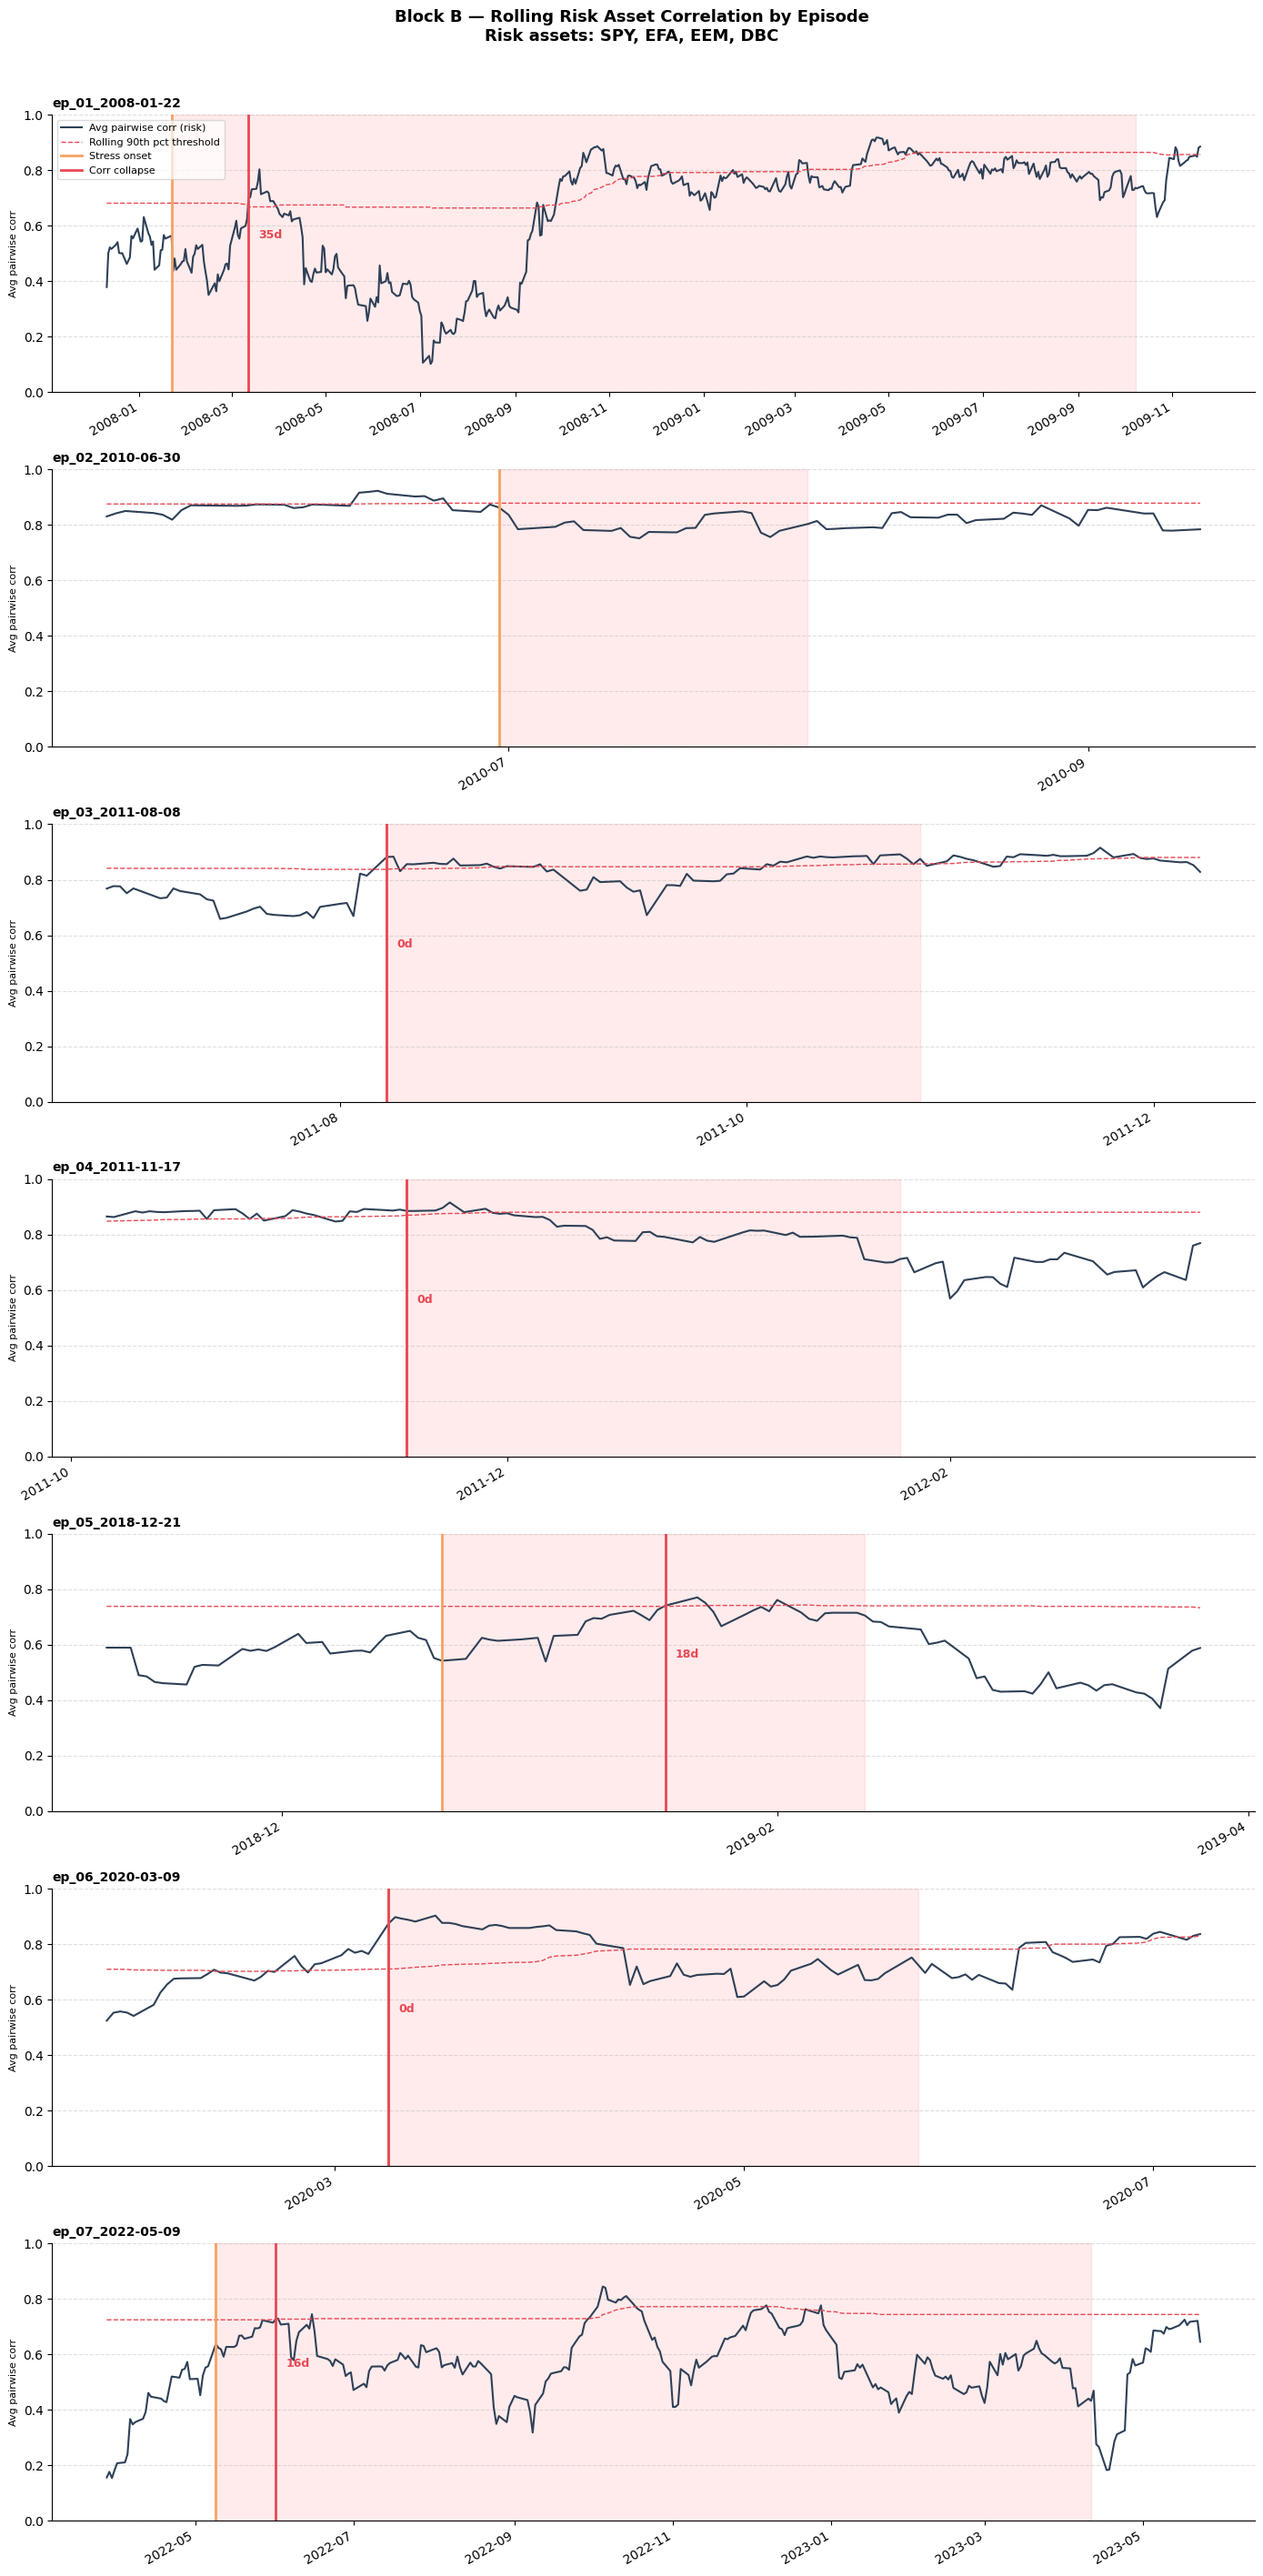

✓ Saved: outputs/fig1_correlation_by_episode_blockB.png


In [569]:
def plot_correlation_by_episode(metrics: pd.DataFrame,
                                 corr_col: str, threshold_col: str,
                                 block_name: str, risk_assets: list,
                                 h2_results: pd.DataFrame = None):
    episodes_list = list(metrics['episode'].dropna().unique())
    n_eps = len(episodes_list)
    fig, axes = plt.subplots(n_eps, 1, figsize=(14, 4 * n_eps))
    if n_eps == 1:
        axes = [axes]

    fig.suptitle(f"{block_name} — Rolling Risk Asset Correlation by Episode\n"
                 f"Risk assets: {', '.join(risk_assets)}",
                 fontsize=13, fontweight='bold', y=1.01)

    # Build lookup dict from h2_results
    h2_lookup = {}
    if h2_results is not None:
        for _, row in h2_results.iterrows():
            if pd.notna(row["days_to_collapse"]) and pd.notna(row["collapse_date"]):
                h2_lookup[row["episode"]] = {
                    "days"         : int(row["days_to_collapse"]),
                    "collapse_date": pd.Timestamp(str(row["collapse_date"])),
                }

    for idx, (ax, ep) in enumerate(zip(axes, episodes_list)):
        ep_dates  = metrics[metrics["episode"] == ep].index
        start     = ep_dates[0]
        end       = ep_dates[-1]
        buf_start = start - pd.offsets.BDay(30)
        buf_end   = end   + pd.offsets.BDay(30)
        data      = metrics.loc[buf_start:buf_end].copy()

        corr      = data[corr_col]
        threshold = data[threshold_col]

        onset_row  = metrics[
            (metrics["stress_onset"] == True) &
            (metrics["episode"] == ep)
        ]
        onset_date = onset_row.index[0] if len(onset_row) > 0 else None

        collapse_date = None
        days          = None
        if ep in h2_lookup:
            days          = h2_lookup[ep]["days"]
            collapse_date = h2_lookup[ep]["collapse_date"]

        ax.axvspan(start, end, alpha=0.08, color='red')
        ax.plot(corr.index, corr.values, color='#2E4057', linewidth=1.5,
                label='Avg pairwise corr (risk)' if idx == 0 else '_nolegend_')
        ax.plot(threshold.index, threshold.values, color='#E84855', linewidth=1.0,
                linestyle='--', label='Rolling 90th pct threshold' if idx == 0 else '_nolegend_')

        if onset_date is not None:
            ax.axvline(onset_date, color='#F4A261', linewidth=2.0,
                       label='Stress onset' if idx == 0 else '_nolegend_')

        if collapse_date is not None:
            ax.axvline(collapse_date, color='#E84855', linewidth=2.0,
                       label='Corr collapse' if idx == 0 else '_nolegend_')
            if days is not None:
                ax.annotate(f'{days}d',
                            xy=(collapse_date, 0.5),
                            xytext=(8, 12), textcoords='offset points',
                            fontsize=9, color='#E84855', fontweight='bold',
                            clip_on=False)

        ax.set_ylim(0.0, 1.0)
        ax.set_title(ep, fontsize=10, fontweight='bold', loc='left')
        ax.set_ylabel("Avg pairwise corr", fontsize=8)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if idx == 0:
            ax.legend(fontsize=8, loc='upper left', framealpha=0.7)

    plt.tight_layout()
    plt.savefig("outputs/fig1_correlation_by_episode_blockB.png",
                dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Saved: outputs/fig1_correlation_by_episode_blockB.png")


os.makedirs("outputs", exist_ok=True)

plot_correlation_by_episode(
    metrics_b,
    corr_col="avg_corr_risk",
    threshold_col="corr_threshold_risk",
    block_name="Block B",
    risk_assets=RISK_ASSETS_B,
    h2_results=h2_b
)

### 6.2 Diversification ratio over time — both blocks

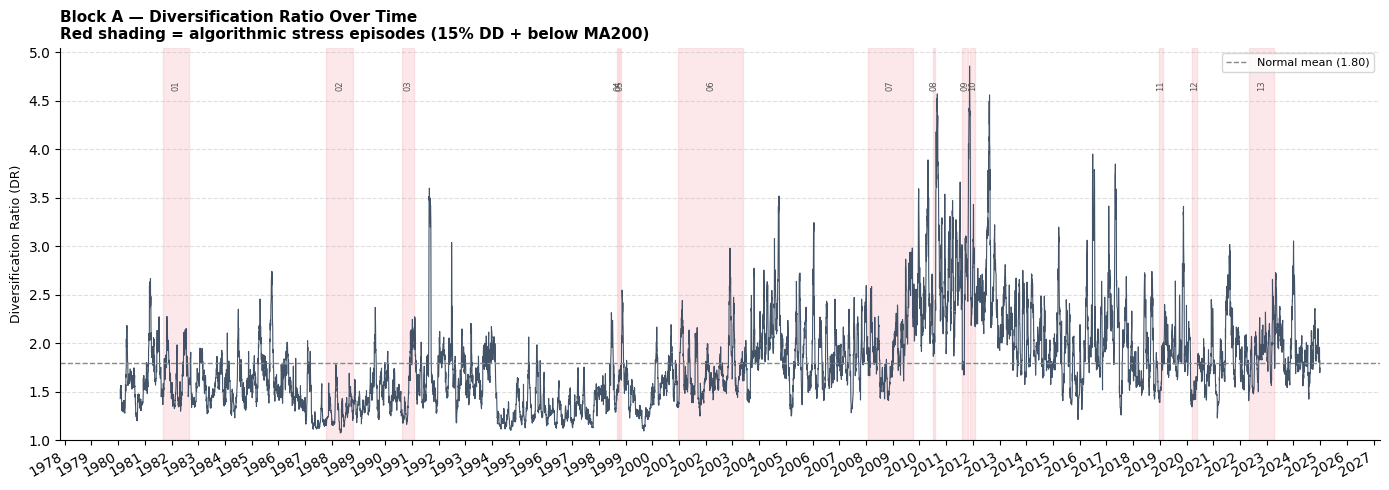

✓ Saved: outputs/fig2_dr_over_time_block_a.png


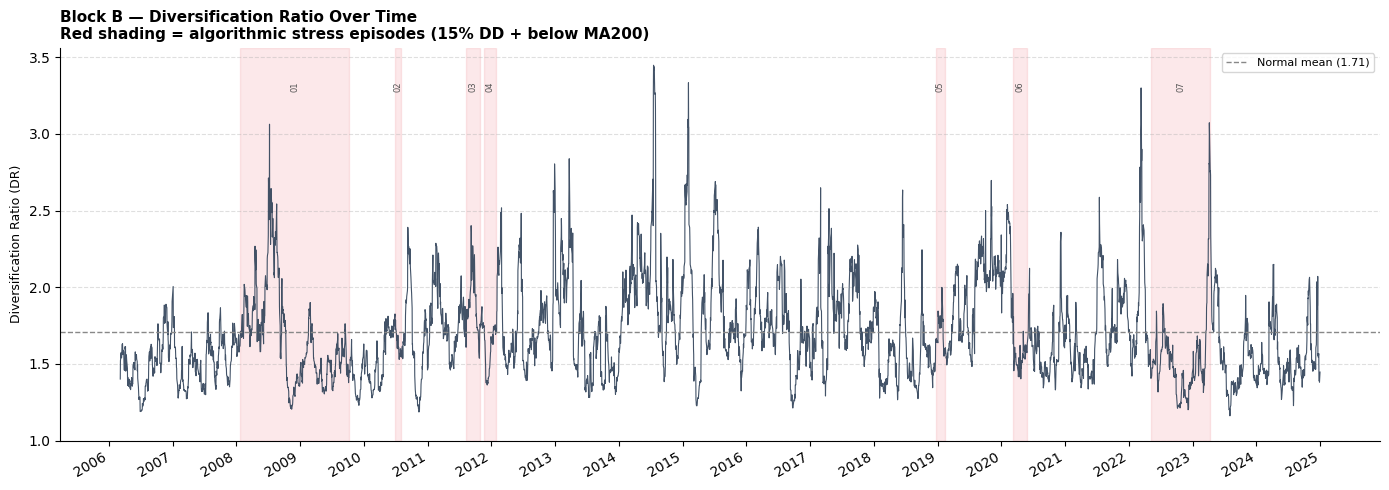

✓ Saved: outputs/fig2_dr_over_time_block_b.png


In [571]:
def plot_dr_over_time(metrics: pd.DataFrame, block_name: str):
    fig, ax = plt.subplots(figsize=(14, 5))

    dr          = metrics["diversification_ratio"].dropna()
    normal_mean = metrics.loc[metrics["regime"] == "normal", "diversification_ratio"].mean()

    ax.plot(dr.index, dr.values, color='#2E4057', linewidth=0.8, alpha=0.9)
    ax.axhline(normal_mean, color='#888888', linewidth=1.0, linestyle='--',
               label=f'Normal mean ({normal_mean:.2f})')

    for ep in metrics['episode'].dropna().unique():
        ep_dates = metrics[metrics["episode"] == ep].index
        start    = ep_dates[0]
        end      = ep_dates[-1]
        ax.axvspan(start, end, alpha=0.12, color='#E84855')
        mid = start + (end - start) / 2
        ax.text(mid, dr.max() * 0.97, ep.split("_")[1] if "_" in ep else ep,
                ha='center', va='top', fontsize=6, color='#555555', rotation=90)

    ax.set_ylim(bottom=1.0)
    ax.set_title(f"{block_name} — Diversification Ratio Over Time\n"
                 f"Red shading = algorithmic stress episodes (15% DD + below MA200)",
                 fontsize=11, fontweight='bold', loc='left')
    ax.set_ylabel("Diversification Ratio (DR)", fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(fontsize=8)

    plt.tight_layout()
    fname = f"outputs/fig2_dr_over_time_{block_name.lower().replace(' ','_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {fname}")


plot_dr_over_time(metrics_a, "Block A")
plot_dr_over_time(metrics_b, "Block B")

### 6.3 Speed of collapse — summary chart

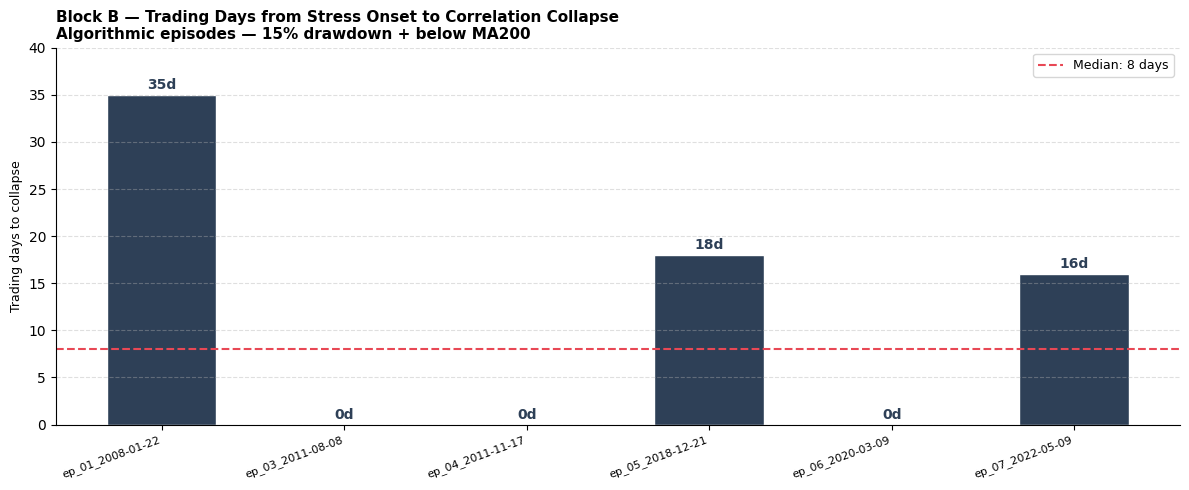

✓ Saved: outputs/fig3_speed_summary.png


In [572]:
def plot_speed_summary(h2_b: pd.DataFrame):
    """
    Bar chart: days to collapse per episode (Block B).
    """
    df = h2_b[h2_b["days_to_collapse"].notna()].copy()
    df["days_to_collapse"] = df["days_to_collapse"].astype(int)
    df["color"] = "#2E4057"

    median_days = int(df["days_to_collapse"].median())

    fig, ax = plt.subplots(figsize=(12, 5))

    bars = ax.bar(df["episode"], df["days_to_collapse"],
                  color=df["color"], width=0.6, edgecolor='white')

    for bar, val in zip(bars, df["days_to_collapse"]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f"{val}d", ha='center', va='bottom',
                fontsize=10, fontweight='bold', color='#2E4057')

    ax.axhline(median_days, color='#E84855', linewidth=1.5,
               linestyle='--', label=f'Median: {median_days} days')

    ax.set_title("Block B — Trading Days from Stress Onset to Correlation Collapse\n"
                 "Algorithmic episodes — 15% drawdown + below MA200",
                 fontsize=11, fontweight='bold', loc='left')
    ax.set_ylabel("Trading days to collapse", fontsize=9)
    ax.set_ylim(0, max(df["days_to_collapse"].max() + 5, 15))
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.xticks(rotation=20, ha='right', fontsize=8)
    plt.tight_layout()

    plt.savefig("outputs/fig3_speed_summary.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Saved: outputs/fig3_speed_summary.png")


plot_speed_summary(h2_b)

## 7. Summary Results

In [573]:
def print_summary_table():
    """
    Consolidated summary of all hypothesis results.
    Pulls p-values and statistics directly from result objects — no hard-coding.
    """
    print("=" * 70)
    print("SUMMARY OF FINDINGS — Project 1: Diversification Doesn't Fail Slowly")
    print("=" * 70)

    # ── H1 ────────────────────────────────────────────────────
    print("\nH1 — Risk Asset Correlation: Stress vs Normal (Block B)")
    print("-" * 70)
    r = h1_results.iloc[0]
    print(f"  Normal baseline (mean)  : {r['mean_corr_normal']:.4f}")
    print(f"  All stress (mean)       : {r['mean_corr_stress']:.4f}")
    print(f"  Mann-Whitney p-value    : {r['p_value']:.4f}  significant={r['significant']}")

    # ── H2 ────────────────────────────────────────────────────
    print("\nH2 — Speed of Collapse")
    print("-" * 70)
    print("  Block B:")
    for _, row in h2_b.iterrows():
        if pd.notna(row["days_to_collapse"]):
            print(f"    {row['episode']:35s}: {int(row['days_to_collapse'])}d")
        else:
            print(f"    {row['episode']:35s}: NOT DETECTED")
    panic_b = h2_b[h2_b["days_to_collapse"].notna()]
    print(f"  Block B median          : {int(panic_b['days_to_collapse'].median())} days")
    print()
    print("  Block A (context):")
    for _, row in h2_a.iterrows():
        if pd.notna(row["days_to_collapse"]):
            print(f"    {row['episode']:35s}: {int(row['days_to_collapse'])}d")
        else:
            print(f"    {row['episode']:35s}: NOT DETECTED")
    panic_a = h2_a[h2_a["days_to_collapse"].notna()]
    if len(panic_a) > 0:
        print(f"  Block A median          : {int(panic_a['days_to_collapse'].median())} days")

    # ── H3 ────────────────────────────────────────────────────
    print("\nH3 — Diversification Ratio: Stress vs Normal")
    print("-" * 70)
    for r in [h3_a.iloc[0], h3_b.iloc[0]]:
        print(f"  {r['block']:8s} — normal: {r['mean_dr_normal']:.4f}  "
              f"stress: {r['mean_dr_stress']:.4f}  "
              f"p={r['p_value']:.4f}  significant={r['significant']}")
    print()
    print("  DR at moment of correlation collapse (Block B):")
    for _, r in dr_collapse_b.iterrows():
        above = "ABOVE" if r["dr_above_normal"] else "below"
        print(f"    {r['episode']:35s}: DR={r['dr_at_collapse']:.4f} ({above} normal)")
    n_above = dr_collapse_b["dr_above_normal"].sum()
    print(f"  DR above normal at collapse: {n_above}/{len(dr_collapse_b)}")

    # ── H4 ────────────────────────────────────────────────────
    print("\nH4 — Breadth Failure: Stress vs Normal")
    print("-" * 70)
    for r in [h4_a.iloc[0], h4_b.iloc[0]]:
        ratio = (r['pct_all_neg_stress'] / r['pct_all_neg_normal']
                 if r['pct_all_neg_normal'] > 0 else 0)
        print(f"  {r['block']:8s} — normal: {r['mean_neg_normal']:.4f}  "
              f"stress: {r['mean_neg_stress']:.4f}  "
              f"all_neg ratio: {ratio:.1f}x  "
              f"p={r['p_value']:.4f}  significant={r['significant']}")

    # ── H5 ────────────────────────────────────────────────────
    print("\nH5 — Universe Expansion Doesn't Help")
    print("-" * 70)
    print(f"  Block B median days to collapse : {int(panic_b['days_to_collapse'].median())} days "
          f"across {len(panic_b)} detected episodes")
    print(f"  Cross-block matching: explicit by onset date (see Section 5.5)")
    print(f"  9 days is not protection — no portfolio can be repositioned in 9 trading days")

    # ── Key finding ───────────────────────────────────────────
    print("\nKey finding not in original scope:")
    print("-" * 70)
    print(f"  {n_above}/{len(dr_collapse_b)} episodes: DR was at or above normal at correlation collapse")
    print(f"  Portfolio appeared diversified while risk side was already highly correlated")
    print(f"  DR is an unreliable real-time indicator of risk-side correlation collapse")

    print("\n" + "=" * 70)


print_summary_table()

SUMMARY OF FINDINGS — Project 1: Diversification Doesn't Fail Slowly

H1 — Risk Asset Correlation: Stress vs Normal (Block B)
----------------------------------------------------------------------
  Normal baseline (mean)  : 0.5771
  All stress (mean)       : 0.6671
  Mann-Whitney p-value    : 0.0000  significant=True

H2 — Speed of Collapse
----------------------------------------------------------------------
  Block B:
    ep_01_2008-01-22                   : 35d
    ep_02_2010-06-30                   : NOT DETECTED
    ep_03_2011-08-08                   : 0d
    ep_04_2011-11-17                   : 0d
    ep_05_2018-12-21                   : 18d
    ep_06_2020-03-09                   : 0d
    ep_07_2022-05-09                   : 16d
  Block B median          : 8 days

  Block A (context):
    ep_01_1981-09-08                   : 131d
    ep_02_1987-10-16                   : 122d
    ep_03_1990-08-23                   : 1d
    ep_04_1998-08-31                   : NOT DETECTED
    ep